In [44]:
# Ensure this notebook can see the repo virtual environment packages.
# This helps when Jupyter/VS Code launches a different Python kernel than expected.
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / ".venv" / "Lib" / "site-packages").exists():
        repo_root = candidate
        break

if repo_root is not None:
    venv_dir = repo_root / ".venv"
    venv_site_packages = venv_dir / "Lib" / "site-packages"
    venv_scripts = venv_dir / "Scripts"
    tensorflow_dir = venv_site_packages / "tensorflow"
    tensorflow_python_dir = tensorflow_dir / "python"

    extra_paths = [venv_site_packages, venv_scripts, tensorflow_dir, tensorflow_python_dir]

    pyvenv_cfg = venv_dir / "pyvenv.cfg"
    if pyvenv_cfg.exists():
        for line in pyvenv_cfg.read_text(encoding="utf-8").splitlines():
            if line.startswith("executable = "):
                extra_paths.append(Path(line.split("=", 1)[1].strip()).parent)
            elif line.startswith("home = "):
                extra_paths.append(Path(line.split("=", 1)[1].strip()))

    if str(venv_site_packages) not in sys.path:
        sys.path.insert(0, str(venv_site_packages))

    os.environ["PATH"] = os.pathsep.join(str(p) for p in extra_paths if p.exists()) + os.pathsep + os.environ.get("PATH", "")

    if hasattr(os, "add_dll_directory"):
        for path in extra_paths:
            if path.exists():
                try:
                    os.add_dll_directory(str(path))
                except OSError:
                    pass

print("Python executable:", sys.executable)
print("Using repo root:", repo_root)


Python executable: C:\Users\Meg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe
Using repo root: X:\ECEsite\Machine-Learning-Class-Repo


## Dataset Loading

The dataset used in this project is the **WM811K wafer defect dataset**, which contains wafer maps produced during semiconductor manufacturing testing. Each wafer map represents the spatial layout of dies (individual chips) on a wafer and whether each die passed or failed electrical testing.

The dataset was exported as a CSV file. Each row contains:

- `waferMap`: a grid representing pass/fail chip locations
- `dieSize`: the size of the dies on the wafer
- `lotName`: the manufacturing lot identifier
- `waferIndex`: the wafer number within the lot
- `trianTestLabel`: indicates whether the wafer belongs to the training or testing set
- `failureType`: the defect pattern classification

We first load the dataset into a pandas DataFrame so that it can be explored and processed.

In [45]:
import pandas as pd


df = pd.read_csv("wm811K_csv_export.csv")

print(df.head())
print(df.info())

                                            waferMap  dieSize lotName  \
0  [[0 0 0 ... 0 0 0]\n [0 0 0 ... 0 0 0]\n [0 0 ...   1683.0    lot1   
1  [[0 0 0 ... 0 0 0]\n [0 0 0 ... 0 0 0]\n [0 0 ...   1683.0    lot1   
2  [[0 0 0 ... 0 0 0]\n [0 0 0 ... 0 0 0]\n [0 0 ...   1683.0    lot1   
3  [[0 0 0 ... 0 0 0]\n [0 0 0 ... 0 0 0]\n [0 0 ...   1683.0    lot1   
4  [[0 0 0 ... 0 0 0]\n [0 0 0 ... 0 0 0]\n [0 0 ...   1683.0    lot1   

   waferIndex  trianTestLabel failureType  
0         1.0  [['Training']]  [['none']]  
1         2.0  [['Training']]  [['none']]  
2         3.0  [['Training']]  [['none']]  
3         4.0  [['Training']]  [['none']]  
4         5.0  [['Training']]  [['none']]  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2 

## Converting Wafer Maps into Numerical Arrays

In the CSV file, the wafer maps are stored as text strings representing matrices. For machine learning, these maps must be converted into numerical arrays.

The `parse_wafer_map` function extracts each row of numbers from the string representation and reconstructs the wafer map as a two‑dimensional NumPy array. This allows the wafer data to be treated as image-like spatial data for later machine learning models.

In [46]:
import numpy as np
import re

def parse_wafer_map(text):

    # extract rows between brackets
    rows = re.findall(r'\[([0-9\s]+)\]', text)

    wafer = []

    for r in rows:
        numbers = [int(x) for x in r.split()]
        wafer.append(numbers)

    return np.array(wafer)

In [47]:
df["waferMap"] = df["waferMap"].apply(parse_wafer_map)

In [48]:
print(type(df["waferMap"][0]))
print(df["waferMap"][0].shape)
print(df["waferMap"][0])

<class 'numpy.ndarray'>
(0,)
[]


## Cleaning Label Fields

The dataset stores some fields such as `failureType` and `trianTestLabel` with additional brackets and quotation marks. These characters are removed using regular expressions so that the labels are stored as simple categorical values.

This step ensures that the defect types can later be used as classification labels.

In [49]:
df["failureType"] = df["failureType"].str.replace(r"[\[\]']", "", regex=True) #remove brackets and quotes
df["trianTestLabel"] = df["trianTestLabel"].str.replace(r"[\[\]']", "", regex=True) 
#remove unlabeled wafers
df = df[df["failureType"] != ""]

## Validating Wafer Maps

Some entries in the dataset may contain malformed wafer maps or arrays that are not valid two-dimensional grids. Before training machine learning models, we verify that each wafer map:

- is a two-dimensional array
- contains valid numerical values
- has non-zero dimensions

Invalid wafer maps are removed to ensure the dataset is consistent and suitable for analysis.

In [50]:
print(df["failureType"].value_counts())

failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


## Standardizing Wafer Map Dimensions

Wafer maps in the dataset can have different grid sizes depending on the manufacturing configuration. CNNs still require a consistent input shape, but cropping larger wafers to **26 x 26** can remove useful spatial information.

In this version, each wafer map is placed on a larger fixed canvas. If a wafer is larger than the canvas, it is scaled down so the full map fits inside the canvas. If it is smaller, it is centered and padded with empty space.

This keeps the full wafer pattern visible while still giving the CNN a consistent image size.

In [51]:
TARGET_SIZE = 64

def valid_map(w):
    w = np.array(w)
    return w.ndim == 2 and w.shape[0] > 0 and w.shape[1] > 0

df = df[df["waferMap"].apply(valid_map)]

def resize_nearest(w, new_shape):
    source_rows = np.linspace(0, w.shape[0] - 1, new_shape[0]).round().astype(int)
    source_cols = np.linspace(0, w.shape[1] - 1, new_shape[1]).round().astype(int)
    return w[np.ix_(source_rows, source_cols)]

def standardize_wafer(w, target_size=TARGET_SIZE):
    w = np.array(w)

    # remove NaN values if they exist
    w = np.nan_to_num(w)

    # ensure it is 2D
    if w.ndim != 2:
        return None

    h, w_ = w.shape

    # Zoom out only when needed, preserving the wafer's aspect ratio.
    scale = min(target_size / h, target_size / w_, 1.0)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w_ * scale)))

    if scale < 1.0:
        fitted = resize_nearest(w, (new_h, new_w))
    else:
        fitted = w

    canvas = np.zeros((target_size, target_size))
    row_start = (target_size - new_h) // 2
    col_start = (target_size - new_w) // 2
    canvas[row_start:row_start + new_h, col_start:col_start + new_w] = fitted[:new_h, :new_w]

    return canvas

df["waferMap"] = df["waferMap"].apply(standardize_wafer)


## Constructing the Machine Learning Dataset

After preprocessing the wafer maps, the data is separated into:

- **X**: the input wafer maps (features)
- **y**: the defect labels (target variable)

The wafer maps are stacked into a three-dimensional NumPy array where each entry corresponds to a wafer image. This format is suitable for both classical machine learning algorithms and deep learning models.

In [52]:
X = np.stack(df["waferMap"].values)
y = df["failureType"].values

print(X.shape)

(74206, 64, 64)


In [53]:
print(X.shape)
print(y.shape)

(74206, 64, 64)
(74206,)


## Encoding Defect Labels

Machine learning models require numerical labels rather than text categories. The `LabelEncoder` from scikit‑learn converts each defect type into a unique integer value.

For example:

- Center → 0
- Donut → 1
- Edge-Loc → 2
- Edge-Ring → 3
- Scratch → 4

This allows the classification algorithms to learn patterns associated with each defect category.

In [54]:
class SimpleLabelEncoder:
    def fit_transform(self, values):
        self.classes_ = np.array(sorted(pd.Series(values).dropna().unique()))
        self.class_to_index_ = {label: idx for idx, label in enumerate(self.classes_)}
        return np.array([self.class_to_index_[label] for label in values])

    def inverse_transform(self, encoded_values):
        return self.classes_[np.array(encoded_values)]

encoder = SimpleLabelEncoder()
y_encoded = encoder.fit_transform(y)
class_names = encoder.classes_


## Splitting the Dataset

To evaluate model performance properly, the dataset is divided into:

- **Training set (80%)** – used to train the models
- **Test set (20%)** – used to evaluate performance on unseen data

This prevents the model from simply memorizing the dataset and provides a more realistic estimate of real-world performance.

In [55]:
def train_test_split_numpy(X, y, test_size=0.2, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = np.arange(len(X))
    rng.shuffle(indices)

    test_count = int(round(len(X) * test_size))
    test_indices = indices[:test_count]
    train_indices = indices[test_count:]

    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

X_train, X_test, y_train, y_test = train_test_split_numpy(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)


In [56]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [57]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

## Baseline Model: Random Forest Classifier

The original notebook included a Random Forest baseline. In `test3`, that baseline is skipped so the notebook can run without the `sklearn` dependency.

The CNN remains the main model and uses the resized, centered wafer-map images directly.

In [58]:
# Random Forest baseline skipped in test3.
# This notebook avoids sklearn so the CNN workflow can run in environments
# where scikit-learn installation is unavailable or unstable.
pred = None
print("Random Forest baseline skipped: sklearn dependency removed in test3.")


Random Forest baseline skipped: sklearn dependency removed in test3.


## Model Evaluation

After training, the model is evaluated using the test dataset.

Two evaluation methods are used:

- **Classification report** – provides precision, recall, and F1-score for each defect class
- **Confusion matrix** – visualizes how often each class is correctly or incorrectly predicted

The confusion matrix helps identify which defect types are easily recognized and which are frequently misclassified.

In [59]:
print("Classification report skipped because Random Forest/sklearn is not used in test3.")


Classification report skipped because Random Forest/sklearn is not used in test3.


## Convolutional Neural Network (CNN)

Wafer maps contain spatial patterns that resemble images. Convolutional Neural Networks (CNNs) are particularly effective for learning spatial features such as clusters, rings, and scratches that occur in wafer defect patterns.

The CNN architecture used in this project consists of:

- Convolutional layers that extract spatial features
- Max-pooling layers that reduce spatial dimensionality
- Fully connected layers that perform classification

The final layer uses a softmax activation function to predict the probability of each defect class.

In [60]:
# OLD CNN MODEL 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np


def compute_balanced_class_weights(y):
    classes, counts = np.unique(y, return_counts=True)
    total = len(y)
    n_classes = len(classes)
    return {int(cls): total / (n_classes * count) for cls, count in zip(classes, counts)}


old_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(TARGET_SIZE,TARGET_SIZE,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

old_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# compute class weights
class_weights = compute_balanced_class_weights(y_train)

print(class_weights)  # just to see values


X:\ECEsite\Machine-Learning-Class-Repo\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{0: np.float64(3.031301062091503), 1: np.float64(388.0065359477124), 2: np.float64(5.0544912728820774), 3: np.float64(16.16693899782135), 4: np.float64(7.833861177091581), 5: np.float64(84.56552706552706), 6: np.float64(31.560340244550773), 7: np.float64(27.714752567693743), 8: np.float64(0.12194245195428365)}


In [61]:
#training the old model
old_history = old_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 32s 39ms/step - accuracy: 0.1846 - loss: 2.0454 - val_accuracy: 0.1094 - val_loss: 2.0692
Epoch 2/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.4131 - loss: 1.4997 - val_accuracy: 0.3046 - val_loss: 1.6168
Epoch 3/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.4595 - loss: 1.4430 - val_accuracy: 0.1119 - val_loss: 2.0580
Epoch 4/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.4971 - loss: 0.9427 - val_accuracy: 0.3249 - val_loss: 1.3337
Epoch 5/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.5493 - loss: 0.7787 - val_accuracy: 0.7362 - val_loss: 0.8739
Epoch 6/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.6119 - loss: 0.5893 - val_accuracy: 0.2357 - val_loss: 1.6005
Epoch 7/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.6754 - loss: 0.4991 - val_accuracy: 0.8039 - val_loss: 0.7242
Epoch 8/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.7221 - loss: 0.4441 - 

In [62]:
#upgraded CNN model with batch normalization and dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential([

    # first conv block
    Conv2D(32, (3,3), activation='relu', input_shape=(TARGET_SIZE,TARGET_SIZE,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # second conv block
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # third conv block (NEW)
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # flatten for dense layers
    Flatten(),

    # dense layer
    Dense(128, activation='relu'),
    Dropout(0.3),  # prevents overfitting

    # output layer
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),  # slower learning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [63]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor='val_loss',
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weights
)

print(history.history['val_loss'])

Epoch 1/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 79s 104ms/step - accuracy: 0.0274 - loss: 2.4372 - val_accuracy: 0.0040 - val_loss: 2.1984
Epoch 2/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 72s 97ms/step - accuracy: 0.0047 - loss: 2.1915 - val_accuracy: 0.0038 - val_loss: 2.1963
Epoch 3/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 71s 95ms/step - accuracy: 0.0140 - loss: 2.1926 - val_accuracy: 0.0038 - val_loss: 2.1975
Epoch 4/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 77s 104ms/step - accuracy: 0.0047 - loss: 2.1914 - val_accuracy: 0.0038 - val_loss: 2.1956
Epoch 5/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 74s 100ms/step - accuracy: 0.0063 - loss: 2.1914 - val_accuracy: 0.0038 - val_loss: 2.1956
Epoch 6/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 76s 102ms/step - accuracy: 0.0238 - loss: 2.1914 - val_accuracy: 0.0038 - val_loss: 2.1931
Epoch 7/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 78s 104ms/step - accuracy: 0.0222 - loss: 2.1914 - val_accuracy: 0.0038 - val_loss: 2.1938
Epoch 8/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 78s 105ms/step - accuracy: 0.0041 - loss: 2.1

In [64]:
# OLD CNN predictions
old_preds = old_model.predict(X_test)
old_preds = np.argmax(old_preds, axis=1)

# NEW CNN predictions
cnn_preds = model.predict(X_test)
cnn_preds = np.argmax(cnn_preds, axis=1)

464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
464/464 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step


In [65]:
# compute metrics for CNN models without sklearn

def accuracy_score_numpy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(y_true == y_pred)


def weighted_f1_score_numpy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    classes = np.unique(y_true)
    total = len(y_true)
    weighted_f1 = 0.0

    for cls in classes:
        true_positive = np.sum((y_true == cls) & (y_pred == cls))
        false_positive = np.sum((y_true != cls) & (y_pred == cls))
        false_negative = np.sum((y_true == cls) & (y_pred != cls))

        precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) else 0.0
        recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        support = np.sum(y_true == cls)
        weighted_f1 += (support / total) * f1

    return weighted_f1

# OLD CNN
cnn_old_acc = accuracy_score_numpy(y_test, old_preds)
cnn_old_f1 = weighted_f1_score_numpy(y_test, old_preds)

# NEW CNN
cnn_acc = accuracy_score_numpy(y_test, cnn_preds)
cnn_f1 = weighted_f1_score_numpy(y_test, cnn_preds)


In [66]:
# comparison of CNN models

print(X_train.shape)
print(X_test.shape)
print(y_train[:10])
print(y_test[:10])
print(cnn_preds[:20])

import pandas as pd

results = pd.DataFrame({
    "Model": ["CNN (Old)", "CNN (Improved)"],
    "Accuracy": [cnn_old_acc, cnn_acc],
    "F1 Score": [cnn_old_f1, cnn_f1]
})

# make it look nice
results["Accuracy"] = results["Accuracy"].round(4)
results["F1 Score"] = results["F1 Score"].round(4)

results


(59365, 64, 64, 1)
(14841, 64, 64, 1)
[8 2 8 8 8 8 8 8 8 8]
[8 8 8 8 8 8 8 8 8 8]
[7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 4]


,Model,Accuracy,F1 Score
0,CNN (Old),0.9604,0.9630
1,CNN (Improved),0.0048,0.0011


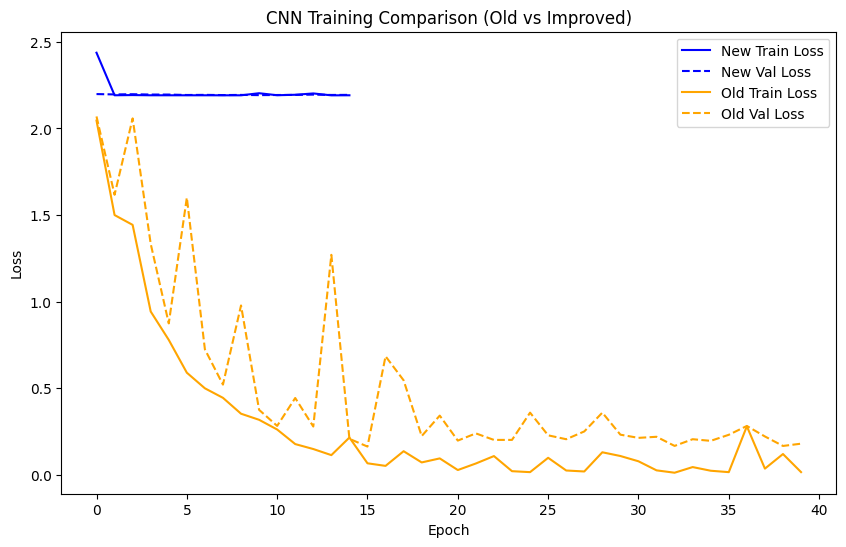

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# NEW MODEL
plt.plot(history.history['loss'], label='New Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='New Val Loss', color='blue', linestyle='dashed')

# OLD MODEL
plt.plot(old_history.history['loss'], label='Old Train Loss', color='orange')
plt.plot(old_history.history['val_loss'], label='Old Val Loss', color='orange', linestyle='dashed')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Comparison (Old vs Improved)")
plt.legend()

plt.show()

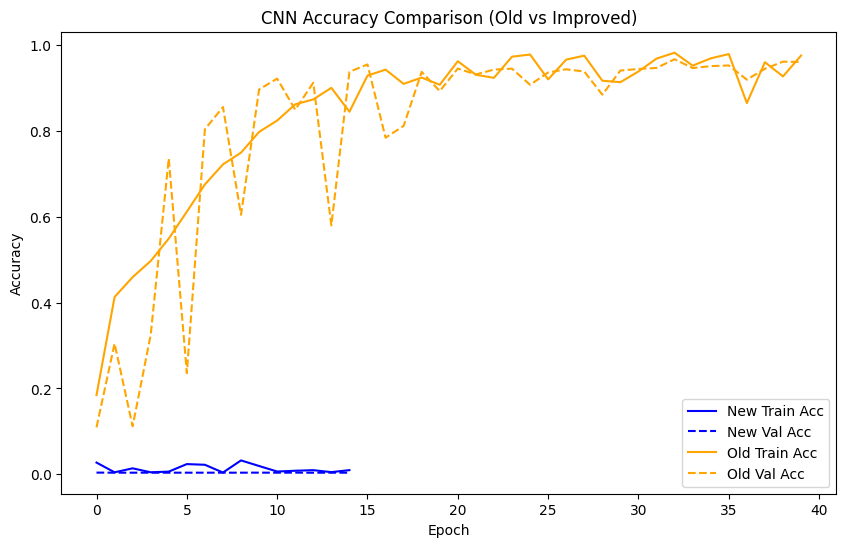

In [68]:
#accuracy comparison
plt.figure(figsize=(10,6))

# NEW MODEL
plt.plot(history.history['accuracy'], label='New Train Acc', color='blue')
plt.plot(history.history['val_accuracy'], label='New Val Acc', color='blue', linestyle='dashed')

# OLD MODEL
plt.plot(old_history.history['accuracy'], label='Old Train Acc', color='orange')
plt.plot(old_history.history['val_accuracy'], label='Old Val Acc', color='orange', linestyle='dashed')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy Comparison (Old vs Improved)")
plt.legend()

plt.show()

In [69]:
pred = model.predict(X_test)
pred = pred.argmax(axis=1)

464/464 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


464/464 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step


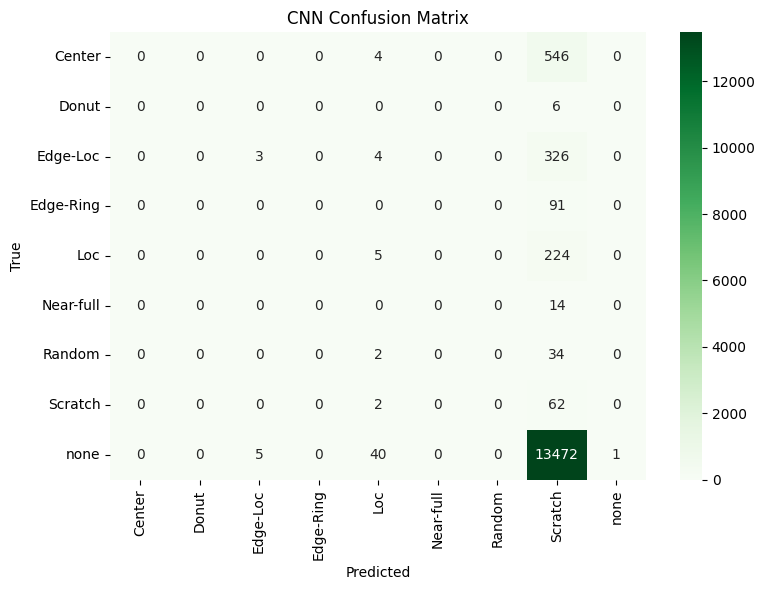

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt


def confusion_matrix_numpy(y_true, y_pred, labels=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
    label_to_index = {label: idx for idx, label in enumerate(labels)}
    matrix = np.zeros((len(labels), len(labels)), dtype=int)

    for actual, predicted in zip(y_true, y_pred):
        matrix[label_to_index[actual], label_to_index[predicted]] += 1

    return matrix

# CNN predictions
cnn_probs = model.predict(X_test)
cnn_preds = np.argmax(cnn_probs, axis=1)

# CNN confusion matrix
labels = np.arange(len(class_names))
cm_cnn = confusion_matrix_numpy(y_test, cnn_preds, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


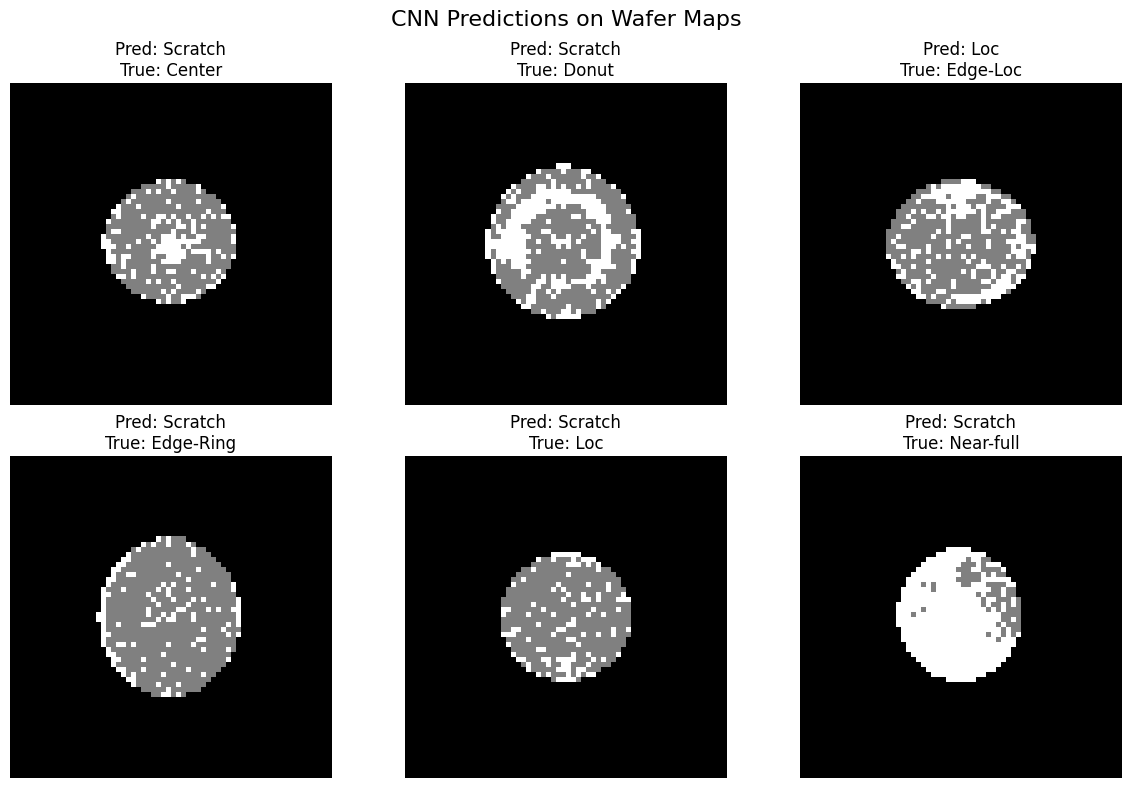

In [71]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# number of samples to show
num_samples = 6

indices = []

# pick one example from each class
for c in range(len(class_names)):
    for i in range(len(y_test)):
        if y_test[i] == c:
            indices.append(i)
            break

# limit to first 6 classes for display
indices = indices[:6]
plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):
    img = X_test[idx]
    true_label = y_test[idx]
    pred_label = cnn_preds[idx]

    plt.subplot(2, 3, i+1)
    plt.imshow(img.squeeze(), cmap="gray")

    plt.title(f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}")
    plt.axis("off")

plt.suptitle("CNN Predictions on Wafer Maps", fontsize=16)
plt.tight_layout()
plt.show()